# Creating a sample of M stars between 50 and 200pc

Benjamin Pennell

--

Max Planck Institut für Astronomie, Heidelberg

---

In [1]:
from utils.dependencies import *;

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import h5py
import pyvo
from astroquery.gaia import Gaia
import matplotlib.patheffects as pe

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


# 1. Prepare all objects nearby

#### Load in the full kpc XP catalogue and take the relevant columns

In [3]:
msms = h5py.File("../BigData/msms_36m_v0.hdf5", "r")
new_table = Table()
labels = ["source_id", "parallax", "ra", "dec", "phot_g_mean_mag", "mass_single", "m1_binary", "m2_binary", "predicted_class", "bp_rp", "mh_single", "q_binary", "flux_ratio_mean", "flux_ratio_std", "chi2_mass_mh", "chi2_mass_mh_binary", "chi2_diff_mh_mass", "fit_success_single", "fit_success_binary"]
for label in labels:
    new_table.add_column(np.array(msms["table"]["columns"][label]["data"]), name=label)

new_table.add_column(np.zeros(len(new_table)), name="mass")

the mass we want to work with is the `mass_single` for objects with `predicted_class=0`, but `m1_binary` if `predicted_class=1`

In [4]:
new_table["mass"] = np.where(new_table["predicted_class"] == 0, new_table["mass_single"], new_table["m1_binary"])

#### Cut to nearby objects in our target mass range

In [9]:
PARALLAX_MASK = (new_table["parallax"] < 20) & (new_table["parallax"] > 5) # 50-200pc
MASS_MASK = (new_table["mass"] < 0.75) & (new_table["mass"] > 0.2)
SUCCESS_CUT = (new_table["fit_success_binary"]) & (new_table["fit_success_single"])
FLUX_RATIO_CUT = new_table["flux_ratio_mean"] < 10**(-1.5)
total_mask = PARALLAX_MASK & MASS_MASK & SUCCESS_CUT & FLUX_RATIO_CUT
working_table = new_table[total_mask]

In [102]:
len(working_table)

453514

In [103]:
working_table.write("./data/2026-06-09_initial_cuts.fits", overwrite=True)

#### (legacy) Save everything within 200pc

In [ ]:
def chunk_list(lst, n):
    """Yield successive n-sized chunks from lst."""
    for i in range(0, len(lst), n):
        yield lst[i:i + n]

batch_size = 25000

everything = []
counter = 0

for batch in tqdm(list(chunk_list(working_table["source_id"], batch_size))):
    ids_str = ",".join(str(sid) for sid in batch)
    query = f"""
    SELECT *
    FROM gaiadr3.gaia_source
    WHERE source_id IN ({ids_str})
    """
    complete = False
    while not complete:
        try:
            job = Gaia.launch_job_async(query, verbose=False)
            results = job.get_results()
            complete = True
        except:
            print(f"{counter} Failed")
        time.sleep(1)

    everything.append(results.to_pandas())
    counter += 1

everything_df = pd.concat(everything, ignore_index=True)

In [59]:
final_df = working_table.to_pandas()

# Merge on source_id
merged_df = final_df.merge(
    everything_df,
    on="source_id",
    how="left",
    suffixes=("", "_gaia")
)

# Convert back to Astropy table if desired
working_table = Table.from_pandas(merged_df)

In [60]:
working_table.write("../BigData/ALL_gaia_source_and_xp_within_200pc.hdf5", path="table", overwrite=True)

# 2. Assign maximum allowable mass ratio

For a paricular metallicity, take an isochrone. Look at the corresponding magnitudes for your two objects and convert that to a flux ratio.

In our case, at the low mass end, the isochrones only go to $0.1M_\odot$, so we need to extrapolate by fitting a power law (this works quite well)

In [10]:
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
isochrone_data = pd.read_csv('./massive_data/PARSEC_logage_6to10_MH_n2p5_0p6_dwarf.csv')

## Make the grid

### Step 1: identify the flux ratio at all valid parts on the isochrone

In [9]:
def flux_ratio(m2, m1, mh, isochrone_data, logAge=9):
    # find the isochrone
    mh_closest = min(np.unique(isochrone_data["MH"]), key=lambda x: abs(x - mh))
    df_mh = isochrone_data[(isochrone_data["MH"] == mh_closest) & (isochrone_data["logAge"] == logAge)].copy()
    df_mh_sorted = df_mh.sort_values('Mini')
    mini_available = df_mh_sorted['Mini'].values
    gmag_available = df_mh_sorted['Gmag'].values
    
    # if the companion is too small, return 0, I'll fill it in later
    if m2 < mini_available.min():
        return 0
    
    # get magnitude for the two masses by interpolating
    interp_gmag = interp1d(mini_available, gmag_available, kind='linear')
    delta_mag = float(interp_gmag(m2)) - float(interp_gmag(m1)) 
    # convert to flux ratio
    flux_ratio = 10**(-0.4*delta_mag) 
    return flux_ratio

In [10]:
q_range = (0.05, 0.5)
mh_range = (-0.5, 0.5)
grid_size = np.array([50, 100, 26])

f_grid = np.zeros(grid_size)
qs = np.linspace(*q_range, grid_size[0])
m1s = np.linspace(0.2, 1.5, grid_size[1])
mhs = np.linspace(*mh_range, grid_size[2])

pbar = tqdm(total=grid_size.prod())
for i, q in enumerate(qs):
    for j, m1 in enumerate(m1s):
        for k, mh in enumerate(mhs):
            model_m2 = q * m1
            model_flux_ratio = flux_ratio(model_m2, m1, mh, isochrone_data)
            f_grid[i,j,k] = model_flux_ratio
            pbar.update(1)

  0%|          | 0/130000 [00:00<?, ?it/s]

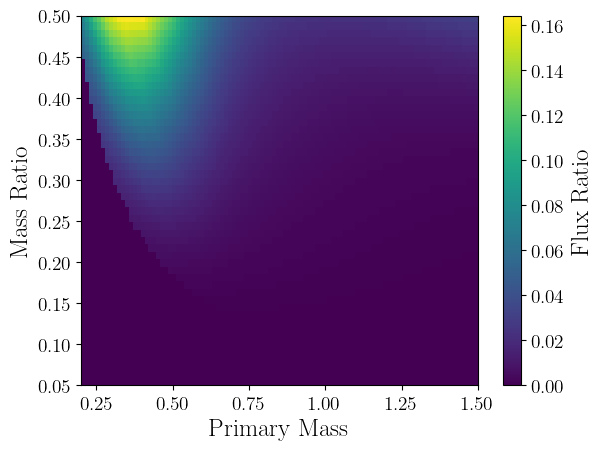

In [11]:
cb = plt.imshow(f_grid[:,:,5], origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), qs.min(), qs.max()]);
plt.xlabel("Primary Mass");
plt.ylabel("Mass Ratio");
plt.colorbar(cb, label="Flux Ratio");

### Step 2: fit power laws along mass ratio axes to fill in remaining spots
here's an example. Approximately gamma=4

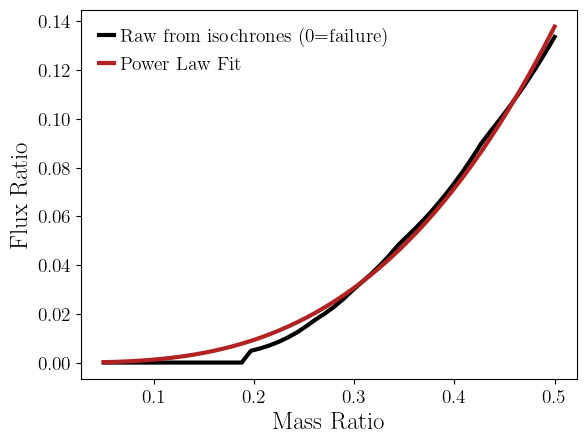

In [12]:
fs = f_grid[:,20,5]
x, y = qs[fs>0], fs[fs>0]
def power_law(x, a, b):
    return a * x**b
popt, pcov = curve_fit(power_law, x, y)
plt.plot(qs, fs, lw=3, label="Raw from isochrones (0=failure)");
plt.plot(qs, power_law(qs, *popt), lw=3, label=f"Power Law Fit");
plt.xlabel("Mass Ratio");
plt.ylabel("Flux Ratio");
plt.legend();

In [13]:
pbar = tqdm(total=grid_size[1]*grid_size[2])
gammas = np.zeros((grid_size[1], grid_size[2]))
for j, m1 in enumerate(m1s):
    for k, mh in enumerate(mhs):
        fs = f_grid[:,j,k]
        mask = fs == 0
        x, y = qs[fs>0], fs[fs>0]
        if len(x) > 2: # have enough points to actually fit a power law decently
            # we have enough points in every column for this to work
            popt, pcov = curve_fit(power_law, x, y)
            f_grid[:,j,k][mask] = power_law(qs, *popt)[mask]
            gammas[j,k] = popt[1]
        pbar.update(1)

  0%|          | 0/2600 [00:00<?, ?it/s]

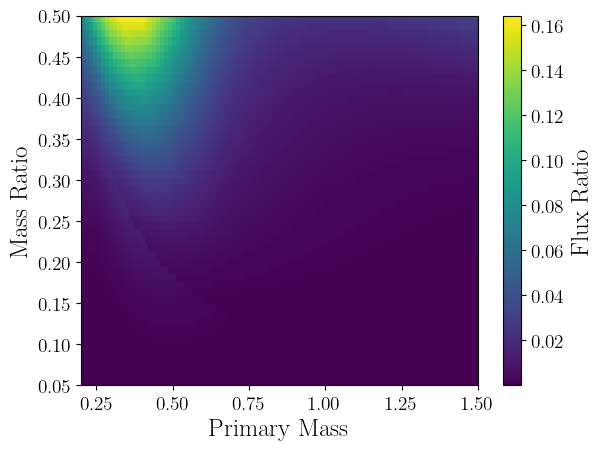

In [14]:
cb = plt.imshow(f_grid[:,:,5], origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), qs.min(), qs.max()]);
plt.xlabel("Primary Mass");
plt.ylabel("Mass Ratio");
plt.colorbar(cb, label="Flux Ratio");

#### simply extend on the other axis

In [15]:
pbar = tqdm(total=grid_size[0]*grid_size[2])
gammas_2 = np.zeros((grid_size[0], grid_size[2]))
f_grid_2 = np.zeros_like(f_grid)
for i, q in enumerate(qs):
    for k, mh in enumerate(mhs):
        mask = (f_grid[i,:,k] == 0)
        f_grid_2[i,:,k] = f_grid[i,:,k]
        if np.sum(mask) == 0:
            continue
        last_point = f_grid_2[i,:,k][~mask][0]
        f_grid_2[i,mask,k] = last_point
        pbar.update(1)

  0%|          | 0/1300 [00:00<?, ?it/s]

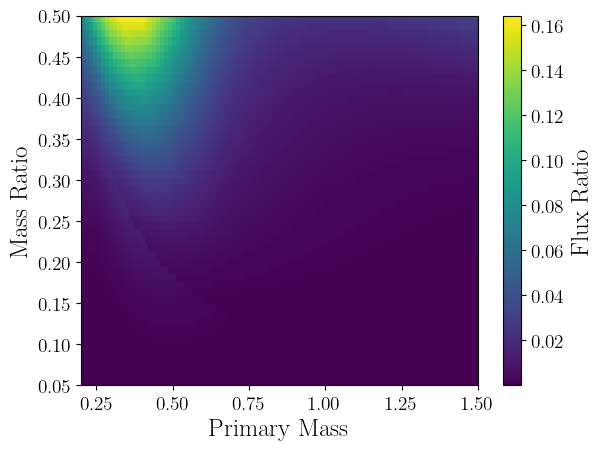

In [16]:
cb = plt.imshow(f_grid_2[:,:,5], origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), qs.min(), qs.max()]);
plt.xlabel("Primary Mass");
plt.ylabel("Mass Ratio");
plt.colorbar(cb, label="Flux Ratio");

Looks lovely. This can be interpolated for any mass/metallicity now.

for interest's sake, we can see what the power law is. It usually sits around 4 but varies considerably. Quite fun.

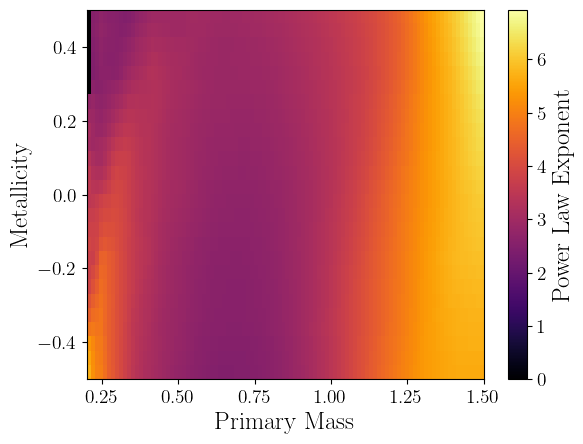

In [17]:
plt.imshow(gammas.T, origin='lower', aspect='auto', extent=[m1s.min(), m1s.max(), mhs.min(), mhs.max()], cmap="inferno");
plt.xlabel("Primary Mass");
plt.ylabel("Metallicity");
plt.colorbar(label="Power Law Exponent");

In [18]:
output = {
    "grid": f_grid_2,
    "gammas": gammas,
    "grid_points": [qs, m1s, mhs],
    "note": """this grid is a representation of a function flux ratio = f(mass ratio, primary mass, metallicity)
                The grid was generated by first computing the flux ratio from isochrones at each point, 
                then fitting power laws to fill in any gaps where the isochrone computation failed because they couldn't reach a low enough mass."""}
pickle.dump(output, open("./data/flux_ratio_grid.pkl", "wb"))

## If we want the flux ratio cut to be $10^{-1.5}$, we can look that up in the grid 

In [ ]:
flux_ratio_grid_sup = pickle.load(open("./data/flux_ratio_grid.pkl", "rb"))
flux_ratio_grid = flux_ratio_grid_sup["grid"]
qs, m1s, mhs = flux_ratio_grid_sup["grid_points"]
working_table = Table.read("./data/2026-06-09_initial_cuts.fits", format='fits')
working_table.add_column(np.zeros(len(working_table)), name="q_max")

In [228]:
fcut = 10**(-1.5)
mh = 0
qmxs = []
for m in m1s:
    mh_idx = np.argmin(np.abs(mhs - mh))
    q_max = np.interp(fcut, flux_ratio_grid[:, np.argmin(np.abs(m1s - m)), mh_idx], qs)
    qmxs.append(q_max)
qmxs = np.array(qmxs)

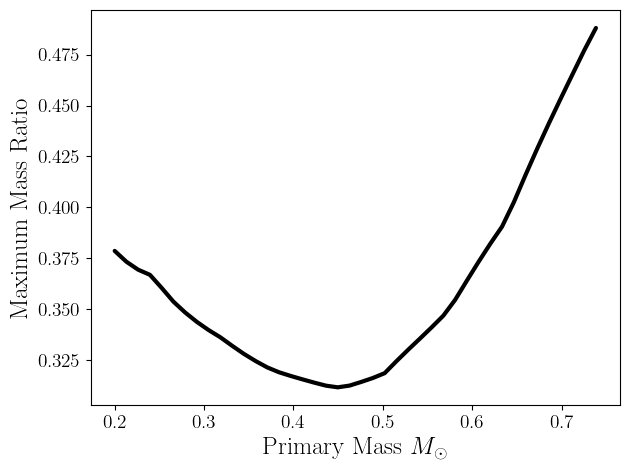

In [61]:
plt.plot(m1s[m1s<0.75], qmxs[m1s<0.75], c="k", lw=3, solid_capstyle='round');
#plt.scatter(massratios["Mini"], massratios["-0.0"], s=10, c="k");
#plt.axvspan(0.2, 0.45, alpha=0.25, color="blue");
plt.xlabel(r"Primary Mass $M_\odot$");
plt.ylabel(r"Maximum Mass Ratio");
plt.tight_layout()
plt.savefig("./plots/MassRatioCutoff.pdf", dpi=800);

In [ ]:
fcut = 10**(-1.5)
q_maxes = []
for row in tqdm(working_table):
    mass_idx = np.argmin(np.abs(m1s - row["mass"]))
    mh_idx = np.argmin(np.abs(mhs - row["mh_single"]))
    q_max = np.interp(fcut, flux_ratio_grid[:, mass_idx, mh_idx], qs)
    q_maxes.append(q_max)
q_maxes = np.array(q_maxes)
working_table["q_max"] = q_maxes
working_table.write('./data/2026_06_09_initial_added_qmax.fits', format='fits', overwrite=True)

  0%|          | 0/379264 [00:00<?, ?it/s]

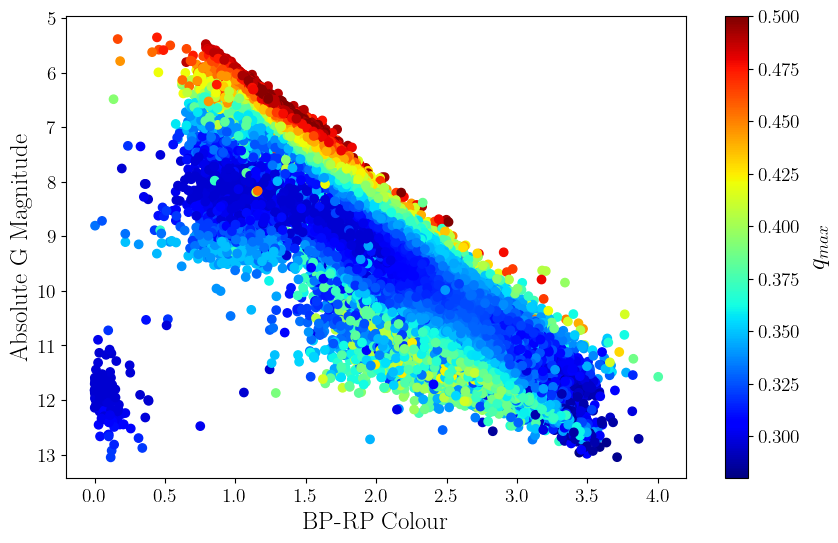

In [107]:
bp_rps = working_table["bp_rp"]
parallax = working_table["parallax"]
gmag = working_table["phot_g_mean_mag"]
absolute_mags = gmag + 5 * np.log10(parallax) - 10

fig, ax = plt.subplots(figsize=(10, 6))
cb = ax.scatter(bp_rps, absolute_mags, c=q_maxes, cmap="jet");
colorbar = plt.colorbar(cb, ax=ax, label=r"$q_{max}$");
ax.invert_yaxis();
ax.set_xlabel("BP-RP Colour");
ax.set_ylabel("Absolute G Magnitude");

# 3. Pulling parameters from Gaia

In [8]:
working_table = Table.read('./data/2026_06_09_initial_added_qmax.fits', format='fits')

### append solution types

In [9]:
nss_table = Table.read('../BigData/NSSTableKpc.fits', format='fits')
accel_table = Table.read('../BigData/AccelTableKpc.fits', format='fits')
nss_table = nss_table[(nss_table["parallax"] < 20) & (nss_table["parallax"] > 5)]
accel_table = accel_table[(accel_table["parallax"] < 20) & (accel_table["parallax"] > 5)]

In [10]:
working_table.add_column(np.zeros(len(working_table)), name="phot_g_mean_flux")
working_table.add_column(np.zeros(len(working_table)), name="phot_g_mean_flux_error")
working_table.add_column(np.zeros(len(working_table)), name="pmra")
working_table.add_column(np.zeros(len(working_table)), name="pmdec")
working_table.add_column(np.zeros(len(working_table)), name="ruwe")
working_table.add_column(np.zeros(len(working_table)), name="solution_type")
working_table["phot_variable_flag"] = np.empty(len(working_table), dtype="U50")

In [11]:
gaia_table = Table.read("../BigData/ALL_gaia_source_and_xp_within_200pc.hdf5", format="hdf5")

In [12]:
mask = np.isin(working_table["source_id"], gaia_table["source_id"])  # boolean mask for rows to update
data_indices = np.where(mask)[0]

# Step 2: Map update indices
update_map = {sid: i for i, sid in enumerate(gaia_table['source_id'])}

# Step 3: Update only the desired columns
for col in ['pmra', 'pmdec', 'ruwe', 'phot_g_mean_flux', 'phot_g_mean_flux_error', 'phot_variable_flag']: #, 'period', 'eccentricity']:
    # Pick corresponding values from updates_df
    working_table[col][data_indices] = [gaia_table[col][update_map[sid]] for sid in working_table['source_id'][data_indices]]

In [13]:
accel_ids = list(accel_table["source_id"])
nss_ids = list(nss_table["source_id"])

for row in tqdm(working_table):
    if row["ruwe"] < 1.4:
        row["solution_type"] = int(0)
    elif row["source_id"] in nss_ids:
        row["solution_type"] = int(12)
    elif row["source_id"] in accel_ids:
        if accel_table[accel_table["source_id"] == row["source_id"]]["nss_solution_type"][0] == "Acceleration7":
            row["solution_type"] = int(7)
        elif accel_table[accel_table["source_id"] == row["source_id"]]["nss_solution_type"][0] == "Acceleration9":
            row["solution_type"] = int(9)
    else:
        row["solution_type"] = int(5)

  0%|          | 0/453514 [00:00<?, ?it/s]

In [14]:
working_table = working_table[working_table["phot_g_mean_flux"] > 0] # successful detection

In [15]:
print_table(working_table, print_latex=True)

Rate (\%) & 92.55 & 6.21 & 0.47 & 0.32 & 0.45 \\
Count & 419597 & 28136 & 2142 & 1448 & 2042 \\


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,92.55,6.21,0.47,0.32,0.45
Counts,453365,419597,28136,2142,1448,2042


In [17]:
working_table.write('./data/2026_06_09_gaia_added.fits', format='fits', overwrite=True)

# 4. Trimming to main sequence with isochrones

In [18]:
total_table = Table.read('../BigData/ALL_gaia_source_and_xp_within_200pc.hdf5', path="table")
working_table = Table.read('./data/2026_06_09_gaia_added.fits', format='fits')

In [21]:
isochrone_data = np.genfromtxt('../DR3_planet_candidate_identification/data/isochrones.dat',
                     skip_header=13,
                     skip_footer=1,
                     names=True,
                     dtype=None)
print(np.unique(isochrone_data["logAge"]))
print(np.unique(isochrone_data["MH"]))

def outside_isochrones(iso_x, iso_y, target_point):
    return np.interp(x=target_point[0], xp=iso_x, fp=iso_y) > target_point[1]

[7.      7.1     7.2     7.3     7.4     7.5     7.6     7.7     7.8
 7.9     8.      8.1     8.2     8.3     8.4     8.5     8.6     8.7
 8.8     8.9     9.      9.1     9.2     9.3     9.4     9.5     9.60001
 9.70001 9.80001 9.90001]
[-0.6 -0.5 -0.4 -0.3 -0.2 -0.1 -0.   0.1  0.2  0.3]


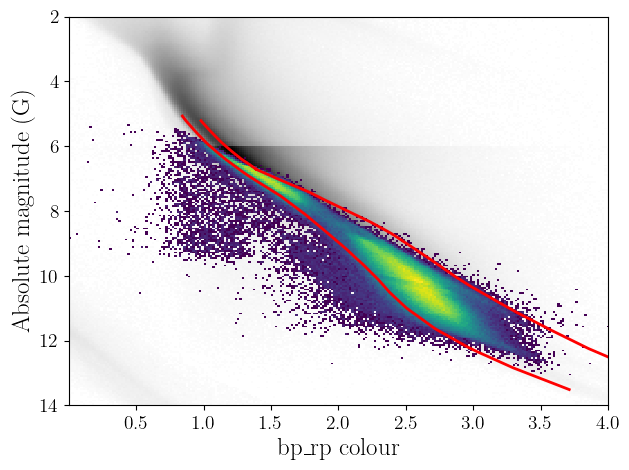

In [22]:
bp_rps = working_table["bp_rp"]
parallax = working_table["parallax"]
gmag = working_table["phot_g_mean_mag"]
absolute_mags = gmag + 5 * np.log10(parallax) - 10

fig, ax = plt.subplots(1, 1)

bp_rp_all = new_table["bp_rp"]
parallax_all = new_table["parallax"]
gmag_all = new_table["phot_g_mean_mag"]
absolute_magnitudes_all = gmag_all + 5 * np.log10(parallax_all) - 10

# --- Background (full dataset) ---
H_bg, xedges, yedges, _ = plt.hist2d(
    bp_rp_all,
    absolute_magnitudes_all,
    bins=300,
    cmap="binary",
    norm=matplotlib.colors.PowerNorm(0.4),
    zorder=1
)

# --- Foreground histogram (compute only) ---
H_fg, _, _ = np.histogram2d(
    bp_rps,
    absolute_mags,
    bins=[xedges, yedges]  # IMPORTANT: same binning
)

# Mask zero bins
H_fg_masked = np.ma.masked_where(H_fg == 0, H_fg)

# Colormap with transparent "bad" values
cmap = plt.cm.viridis.copy()
cmap.set_bad(alpha=0)  # <-- makes masked bins invisible

# Plot foreground
plt.pcolormesh(
    xedges,
    yedges,
    H_fg_masked.T,
    cmap=cmap,
    norm=matplotlib.colors.PowerNorm(0.4),
    zorder=2
)

# fig, ax = plt.subplots(1, 1)

#plt.hist2d(bp_rps, absolute_mags, bins=1000, norm=matplotlib.colors.PowerNorm(0.4));

isochrone_mags = isochrone_data["Gmag"]
isochrone_cols = isochrone_data["G_BPmag"] - isochrone_data["G_RPmag"]
edge_mask = (isochrone_cols < 4.5) & (isochrone_mags > 5) & (isochrone_mags < 14) & (isochrone_data["MH"] == -0.3) & (isochrone_data["logAge"] == 9.90001)
edge_isochrone_cols, edge_isochrone_mags = isochrone_cols[edge_mask], isochrone_mags[edge_mask]
plt.plot(edge_isochrone_cols, edge_isochrone_mags, c="r", linewidth=2, label="M/H=-0.3, logAge=9.9");

isochrone_mags = isochrone_data["Gmag"]
isochrone_cols = isochrone_data["G_BPmag"] - isochrone_data["G_RPmag"]
upper_mask = (isochrone_mags < 14) & (isochrone_mags > 5) & (isochrone_cols < 5) & (isochrone_data["MH"] == 0.3) & (isochrone_data["logAge"] == 7.8)
edge_isochrone_cols, edge_isochrone_mags = isochrone_cols[upper_mask], isochrone_mags[upper_mask]
plt.plot(edge_isochrone_cols, edge_isochrone_mags, c="r", linewidth=2);

ax.invert_yaxis()
ax.set_ylim([14, 2])
ax.set_xlim(right=4)#[0.5,4])
ax.set_ylabel("Absolute magnitude (G)");
ax.set_xlabel("bp_rp colour");

plt.tight_layout();
plt.savefig("./plots/isochrone_cuts.jpg", dpi=800);

In [23]:
def get_sorted_isochrone_points(isochrone_mags, isochrone_cols, edge_mask, get_edgevals=False):
    edge_isochrone_cols, edge_isochrone_mags = isochrone_cols[edge_mask], isochrone_mags[edge_mask]
    if get_edgevals:
        return edge_isochrone_cols, edge_isochrone_mags
    coords = list(zip(edge_isochrone_mags, edge_isochrone_cols))
    coords.sort()
    x_sorted, y_sorted = zip(*coords)
    return x_sorted, y_sorted

x_sorted, y_sorted = get_sorted_isochrone_points(isochrone_mags, isochrone_cols, edge_mask)

u_x_sorted, u_y_sorted = get_sorted_isochrone_points(isochrone_mags, isochrone_cols, upper_mask)

isochrone_mask = np.invert(outside_isochrones(x_sorted, y_sorted, (absolute_mags, bp_rps))) & outside_isochrones(u_x_sorted, u_y_sorted, (absolute_mags, bp_rps))
isochrone_cut = working_table[isochrone_mask]
rejected = working_table[np.invert(isochrone_mask)]

In [202]:
len(isochrone_cut), len(rejected), f"{len(rejected)/len(working_table)*100:.2f}% rejected by isochrone cut"

(426309, 27205, '6.00% rejected by isochrone cut')

# 5. Magnitude error cut

In [29]:
delta_gs = working_table["phot_g_mean_flux_error"]/working_table["phot_g_mean_flux"]
masses = working_table["mass"]

percs = np.linspace(0,100,21)
lims = np.zeros(len(percs)-1)
for i in range(len(percs)-1):
    subset_mask = (working_table["phot_g_mean_flux"] > 0) & (masses > np.percentile(masses, percs[i])) & (masses < np.percentile(masses, percs[i+1]))
    lims[i] = np.percentile(delta_gs[subset_mask], 95)
under_mask = np.zeros(len(working_table), dtype=bool)

edges = np.percentile(masses, percs)
mass_arr = np.asarray(working_table["mass"])
err = np.asarray(working_table["phot_g_mean_flux_error"]) / np.asarray(working_table["phot_g_mean_flux"])
bin_idx = np.searchsorted(edges, mass_arr, side="right") - 1
bin_idx = np.clip(bin_idx, 0, len(lims) - 1)
under_mask = err < lims[bin_idx]

# 6. Make NSS table

In [4]:
final_table = Table.read('./data/2026_06_09_final_table.fits', format='fits')
nss_table = Table.read('../BigData/NSSTableKpc.fits', format='fits')
nss_table = nss_table[(nss_table["parallax"] < 20) & (nss_table["parallax"] > 5)]

In [5]:
len(final_table[final_table["mass"] < 0.65])

330368

In [6]:
relevant_things = ["source_id", "parallax", "ra", "dec", "phot_g_mean_mag", "mass_single", "m1_binary", "m2_binary", "predicted_class", "bp_rp", "mh_single", "q_binary", "flux_ratio_mean", "flux_ratio_std", "chi2_mass_mh", "chi2_mass_mh_binary", "chi2_diff_mh_mass", "fit_success_single", "fit_success_binary"]
for col in relevant_things:
    if col not in nss_table.keys():
        nss_table.add_column(np.zeros(len(nss_table)), name=col)

In [7]:
reduced_nss = Table(names=nss_table.colnames, dtype=[nss_table[col].dtype for col in nss_table.colnames])
for obj in tqdm(nss_table):
    source_id = obj["source_id"]
    if source_id in final_table["source_id"]:
        target_row = final_table[final_table["source_id"] == source_id][0]
        for col in relevant_things:
            obj[col] = target_row[col]
                
        reduced_nss.add_row(obj)

  0%|          | 0/16504 [00:00<?, ?it/s]

In [8]:
labels = ["m2", "fm"]
for label in labels:
    try:
        reduced_nss.add_column(np.zeros(len(reduced_nss)), name=label)
    except:
        pass
    
for row in tqdm(reduced_nss):
    result_row = reduced_nss[reduced_nss["source_id"] == row["source_id"]]
    row["fm"] = mass_function(result_row[0])
    row["m2"] = companion_mass(row["mass_single"], row["fm"])

  0%|          | 0/1560 [00:00<?, ?it/s]

In [10]:
reduced_nss.write("./data/2026_06_09_orbit_solutions.fits", overwrite=True)

# 7 Look at those cuts!

In [25]:
variability_mask = working_table["phot_variable_flag"] == "VARIABLE"

In [30]:
print_table(working_table, print_latex=True)
print_table(working_table[~isochrone_mask], print_latex=True)
print_table(working_table[variability_mask], print_latex=True)
print_table(working_table[~under_mask], print_latex=True)
print_table(working_table[(~isochrone_mask) | (variability_mask) | (~under_mask)], print_latex=True)
print_table(working_table[(isochrone_mask) & (~variability_mask) & (under_mask)], print_latex=True)

Rate (\%) & 92.55 & 6.21 & 0.47 & 0.32 & 0.45 \\
Count & 419597 & 28136 & 2142 & 1448 & 2042 \\


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,92.55,6.21,0.47,0.32,0.45
Counts,453365,419597,28136,2142,1448,2042


Rate (\%) & 75.54 & 22.66 & 0.40 & 0.47 & 0.94 \\
Count & 20439 & 6129 & 106 & 127 & 254 \\


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,75.54,22.66,0.40,0.47,0.94
Counts,27057,20439,6129,106,127,254


Rate (\%) & 90.60 & 7.22 & 0.79 & 0.60 & 0.79 \\
Count & 29217 & 2328 & 256 & 193 & 256 \\


...

,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,37.97,61.60,0.16,0.14,0.13
Counts,22680,8612,13970,37,31,30


Rate (\%) & 74.77 & 23.64 & 0.50 & 0.43 & 0.65 \\
Count & 55259 & 17473 & 367 & 320 & 483 \\


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,74.77,23.64,0.50,0.43,0.65
Counts,73902,55259,17473,367,320,483


Rate (\%) & 96.01 & 2.81 & 0.47 & 0.30 & 0.41 \\
Count & 364338 & 10663 & 1774 & 1128 & 1559 \\


,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,96.01,2.81,0.47,0.30,0.41
Counts,379463,364338,10663,1774,1128,1559


In [36]:
final_table = working_table[(isochrone_mask) & (~variability_mask) & (under_mask)]
final_table.write('./data/2026_06_09_final_table.fits', format='fits', overwrite=True)

In [38]:
len(final_table[final_table["mass"] < 0.65])

330368

# So, what have we got?

In [39]:
final_table = Table.read('./data/2026_06_09_final_table.fits', format='fits')

In [40]:
bincount = 20
masses = np.percentile(final_table["mass"], np.linspace(0,100,bincount+1))
r = np.zeros(bincount)
ruwes = np.zeros(bincount)
for i in range(bincount):
    tcat = final_table[(final_table["mass"] > masses[i]) & (final_table["mass"] <= masses[i+1])]
    rate = len(tcat[[t["solution_type"] == 0 for t in tcat]])/len(tcat)*100
    r[i] = rate
    ruwes[i] = np.median(tcat["ruwe"])
    #print_table(tcat, label=f"Mass: {masses[i]:.3f}-{masses[i+1]:.3f}")

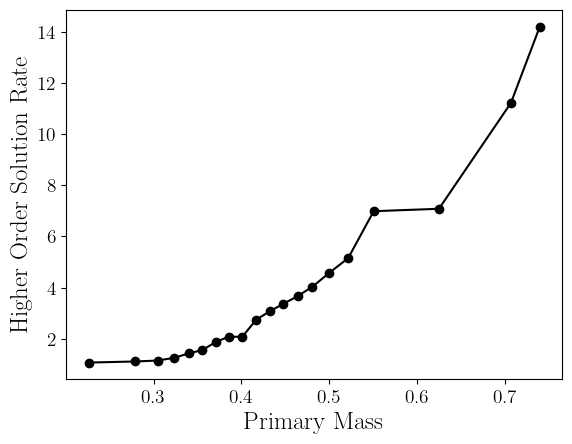

In [41]:
plt.plot(masses[:-1]+(masses[1]-masses[0])/2, 100-r, marker="o");
plt.xlabel("Primary Mass");
plt.ylabel("Higher Order Solution Rate");

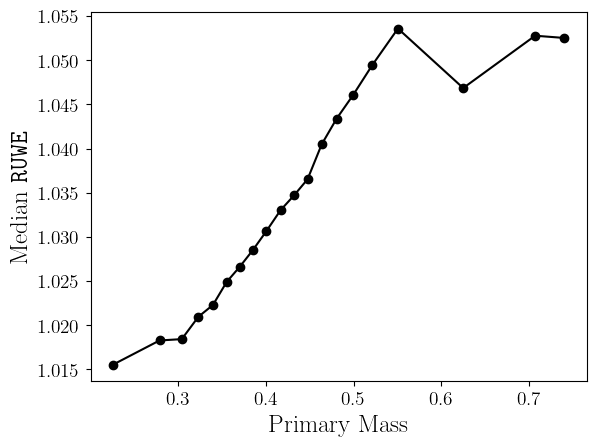

In [42]:
plt.plot(masses[:-1]+(masses[1]-masses[0])/2, ruwes, marker="o");
plt.xlabel("Primary Mass");
plt.ylabel(r"Median $\texttt{RUWE}$");

## "corner" plot

In [44]:
final_table = Table.read('./data/2026_06_09_final_table.fits', format='fits')

In [45]:
final_table["distance"] = 1000/final_table["parallax"]
final_table["logruwe"] = np.log10(final_table["ruwe"])

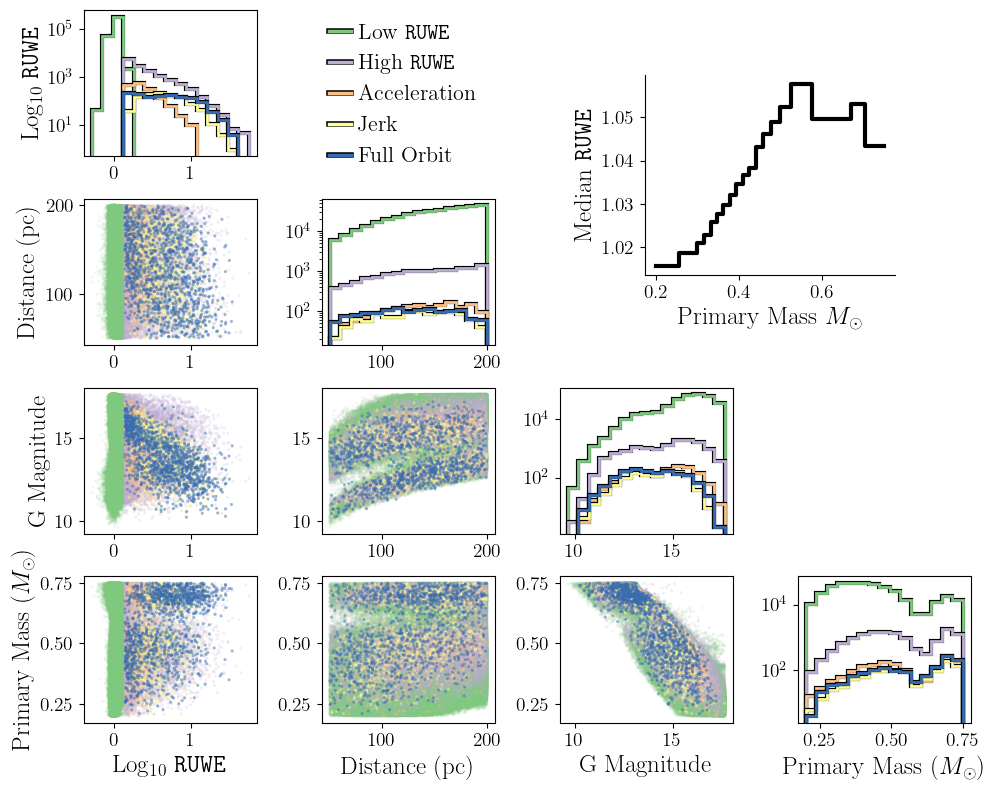

In [13]:
params = ["logruwe", "distance", "phot_g_mean_mag", "mass"]
labels = [r"\text{Log}$_{10}$ \texttt{RUWE}", "Distance (pc)", "G Magnitude", r"Primary Mass ($M_\odot$)"]
type_labels = [r"Low \texttt{RUWE}", r"High \texttt{RUWE}", "Acceleration", "Jerk", "Full Orbit"]
soltypes = [0,5,7,9,12]
colors = plt.get_cmap('Accent')(np.linspace(0, 1, 8))[:5]

n = len(params)
fig, axes = plt.subplots(n, n, figsize=(10, 8))

nbins=15
ruwe_bins = np.linspace(np.min(final_table["logruwe"]), np.max(final_table["logruwe"]), nbins+1)
dist_bins = np.linspace(np.min(final_table["distance"]), np.max(final_table["distance"]), nbins+1)
mag_bins = np.linspace(np.min(final_table["phot_g_mean_mag"]), np.max(final_table["phot_g_mean_mag"]), nbins+1)
mass_bins = np.linspace(np.min(final_table["mass"]), np.max(final_table["mass"]), nbins+1)
bin_sets = [ruwe_bins, dist_bins, mag_bins, mass_bins]

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i < j:
            ax.axis('off')
            continue

        for t in range(5):
            subset = final_table[final_table["solution_type"] == soltypes[t]]
            x = subset[params[j]]
            y = subset[params[i]]

            if i == j:
                ax.hist(x, color=colors[t],histtype="step", bins=bin_sets[i], lw=2, 
                        path_effects=[pe.Stroke(linewidth=3, foreground='black'), pe.Normal()])
                ax.set_yscale("log")
            else:
                ax.scatter(x, y, s=5, color=colors[t], alpha=0.1*(t+1), edgecolor="none")

        if i == n-1:
            ax.set_xlabel(labels[j])
        if j == 0:
            ax.set_ylabel(labels[i])

# Create legend handles
handles = [
    matplotlib.lines.Line2D([0, 1], [0, 0],      # defines a line segment
           color=colors[t],     # your color per type
           lw=2.5,              # line width
           linestyle='-',       # solid line (can change)
           label=type_labels[t],
           path_effects=[
               pe.Stroke(linewidth=4, foreground='black'),  # outline
               pe.Normal()                                  # actual line on top
           ])
    for t in range(5)
]

# Add legend to figure (not individual axes)
fig.legend(
    handles=handles,
    loc='upper right',
    bbox_to_anchor=(0.50, 0.99),
    frameon=False,       # removes boundary box
    fontsize=16,         # bigger text
    handlelength=1,      # longer lines
)

plt.tight_layout()

inset_ax = fig.add_axes([0.65, 0.65, 0.25, 0.25]) 

# compute bins for drawing
mass_lims_b = np.percentile(final_table["mass"], np.linspace(0,100,bincount+1))
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

# draw median RUWE
pts = ruwes
inset_ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(pts,2), lw=3);
inset_ax.set_xlabel(r"Primary Mass $M_\odot$");
inset_ax.set_ylabel(r"Median \texttt{RUWE}");
inset_ax.spines['top'].set_visible(False)
inset_ax.spines['right'].set_visible(False)

#plt.savefig("./plots/SampleCorner.jpg", dpi=800);

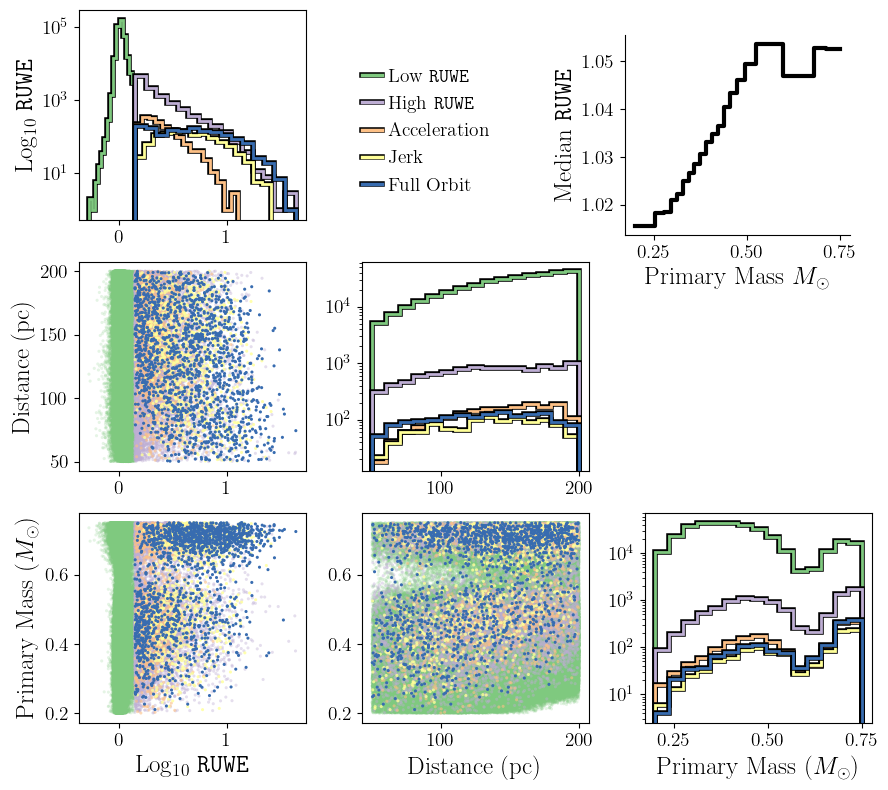

In [46]:
params = ["logruwe", "distance", "mass"]
labels = [r"\text{Log}$_{10}$ \texttt{RUWE}", "Distance (pc)", r"Primary Mass ($M_\odot$)"]
type_labels = [r"Low \texttt{RUWE}", r"High \texttt{RUWE}", "Acceleration", "Jerk", "Full Orbit"]

soltypes = [0, 5, 7, 9, 12]
colors = plt.get_cmap('Accent')(np.linspace(0, 1, 8))[:5]

n = len(params)
fig, axes = plt.subplots(n, n, figsize=(9, 8))

nbins = 15
dist_bins = np.linspace(np.min(final_table["distance"]), np.max(final_table["distance"]), nbins + 1)
mass_bins = np.linspace(np.min(final_table["mass"]), np.max(final_table["mass"]), nbins + 1)
bin_sets = [nbins, dist_bins, mass_bins]

for i in range(n):
    for j in range(n):
        ax = axes[i, j]

        if i < j: ax.axis("off"); continue

        for t in range(5):
            subset = final_table[final_table["solution_type"] == soltypes[t]]
            x, y = subset[params[j]], subset[params[i]]

            if i == j:
                ax.hist(x, color=colors[t], bins=bin_sets[i], histtype="step", lw=2,
                        path_effects=[pe.Stroke(linewidth=4, foreground='black'), pe.Normal()])
                ax.set_yscale("log")
            else:
                ax.scatter(x, y, s=5, color=colors[t], edgecolors="none", alpha=0.2 * (t + 1))

        if i == n - 1: ax.set_xlabel(labels[j])
        if j == 0: ax.set_ylabel(labels[i])

handles = [matplotlib.lines.Line2D([0, 1], [0, 0], color=colors[t], lw=2.5, linestyle='-',
                                   label=type_labels[t],
                                   path_effects=[pe.Stroke(linewidth=4, foreground='black'), pe.Normal()])
           for t in range(5)]

fig.legend(handles=handles, loc='upper right', bbox_to_anchor=(0.57, 0.93),
           frameon=False, fontsize=14, handlelength=1)

plt.tight_layout()

inset_ax = fig.add_axes([0.70, 0.70, 0.25, 0.25])

mass_lims_b = np.percentile(final_table["mass"], np.linspace(0, 100, bincount + 1))
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2
pts = ruwes

inset_ax.plot(np.repeat(mass_lims_b, 2)[1:-1], np.repeat(pts, 2), lw=3)
inset_ax.set_xlabel(r"Primary Mass $M_\odot$")
inset_ax.set_ylabel(r"Median \texttt{RUWE}")

inset_ax.spines['top'].set_visible(False)
inset_ax.spines['right'].set_visible(False)

plt.savefig("./plots/SampleCorner.jpg", dpi=800)
plt.show()

# Magnitude cut plot

In [3]:
mdwarfs = Table.read('./data/2026_06_09_gaia_added.fits', format='fits')

In [4]:
delta_gs = mdwarfs["phot_g_mean_flux_error"]/mdwarfs["phot_g_mean_flux"]
masses = mdwarfs["mass"]

percs = np.linspace(0,100,21)
lims = np.zeros(len(percs)-1)
for i in range(len(percs)-1):
    subset_mask = (mdwarfs["phot_g_mean_flux"] > 0) & (masses > np.percentile(masses, percs[i])) & (masses < np.percentile(masses, percs[i+1]))
    lims[i] = np.percentile(delta_gs[subset_mask], 95)

In [5]:
under_mask = np.zeros(len(mdwarfs), dtype=bool)

edges = np.percentile(masses, percs)
mass_arr = np.asarray(mdwarfs["mass"])
err = np.asarray(mdwarfs["phot_g_mean_flux_error"]) / np.asarray(mdwarfs["phot_g_mean_flux"])
bin_idx = np.searchsorted(edges, mass_arr, side="right") - 1
bin_idx = np.clip(bin_idx, 0, len(lims) - 1)
under_mask = err < lims[bin_idx]

In [57]:
base = plt.get_cmap('Reds')

# Skip the bottom 10%
colors = base(np.linspace(0.2, 1.0, 256))
reds_truncated = matplotlib.colors.ListedColormap(colors)

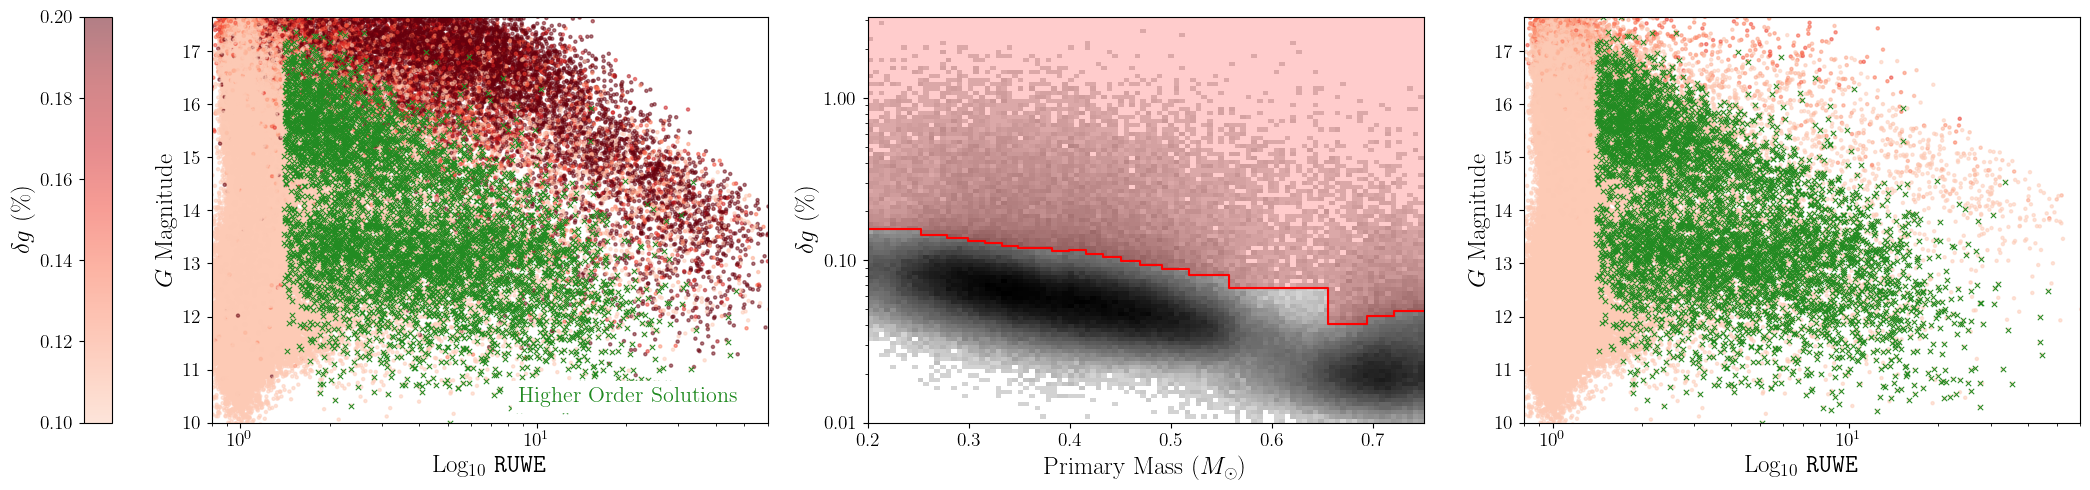

In [66]:
fig = plt.figure(figsize=(21, 5))
gs = fig.add_gridspec(1, 4, width_ratios=[0.05, 1, 1, 1])

cax = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax3 = fig.add_subplot(gs[3])

# SCATTER WITH HIGHER ORDER SOLUTIONS
ax = ax1
cols = np.clip(mdwarfs["phot_g_mean_flux_error"]/mdwarfs["phot_g_mean_flux"], 1e-3, 0.002)*100
sc = ax.scatter(mdwarfs["ruwe"], mdwarfs["phot_g_mean_mag"], s=5, alpha=0.5, c=cols, cmap=reds_truncated);#, norm=matplotlib.colors.PowerNorm(0.3, vmin=cols.min(), vmax=cols.max()));
ax.scatter(mdwarfs[mdwarfs["solution_type"] > 5]["ruwe"], mdwarfs[mdwarfs["solution_type"] > 5]["phot_g_mean_mag"], lw=0.75, s=15, marker="x", color="forestgreen", label="Higher Order Solutions");
ax.set_xscale("log");
ax.set_xlabel(r"Log$_{10}$ $\texttt{RUWE}$");
ax.set_ylabel(r"$G$ Magnitude");
ax.text(transform=ax.transAxes, x=0.55, y=0.05, s="Higher Order Solutions", color="forestgreen", fontsize=16, fontweight="heavy", backgroundcolor="white", zorder=2);
ax.set_ylim([10,17.65])
ax.set_xlim([0.8,60])

cb = fig.colorbar(sc, cax=cax, label=r"$\delta g~(\%)$");
cb.ax.yaxis.set_ticks_position("left")
cb.ax.yaxis.set_label_position("left")

## SHOW THE MASS-DEPENDANT CUT
ax = ax2
y_bins = np.logspace(-2, 0.5, 100)
ax.hist2d(mdwarfs["mass"], mdwarfs["phot_g_mean_flux_error"]/mdwarfs["phot_g_mean_flux"]*100, bins=(100, y_bins), cmap="Greys", norm=matplotlib.colors.PowerNorm(0.2));
bounds = np.array([np.percentile(masses, p) for p in percs])
ax.plot(bounds.repeat(2)[1:-1], lims.repeat(2)*100, c="r", label=r"Binned 95 Percentile Cut")
ax.fill_between(bounds.repeat(2)[1:-1], lims.repeat(2)*100, 5, color="r", alpha=0.2, label="Removed objects")
ax.set_xlabel(r"Primary Mass ($M_\odot$)");
ax.set_ylabel(r"$\delta g~(\%)$");
ax.set_xlim([0.2, 0.75])
ax.set_yscale("log")
ax.yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
ax.yaxis.get_major_formatter().set_scientific(False)

## SCATTER WITH THE OBJECTS REMOVED
ax = ax3
cut_mdwarfs = mdwarfs[under_mask]
cmin=cols.min()
cmax=cols.max()
cols = np.clip(cut_mdwarfs["phot_g_mean_flux_error"]/cut_mdwarfs["phot_g_mean_flux"], 1e-3, 0.002)*100
sc = ax.scatter(cut_mdwarfs["ruwe"], cut_mdwarfs["phot_g_mean_mag"], s=5, alpha=0.5, c=cols, cmap=reds_truncated, vmin=cmin, vmax=cmax);
ax.scatter(cut_mdwarfs[cut_mdwarfs["solution_type"] > 5]["ruwe"], cut_mdwarfs[cut_mdwarfs["solution_type"] > 5]["phot_g_mean_mag"], lw=0.75, s=15, marker="x", color="forestgreen", label="Higher Order Solutions");
ax.set_xscale("log");
ax.set_xlabel(r"Log$_{10}$ $\texttt{RUWE}$");
ax.set_ylabel(r"$G$ Magnitude");
ax.set_ylim([10,17.65])
ax.set_xlim([0.8,60])

plt.tight_layout()
plt.savefig("./plots/FluxError.png", dpi=600, transparent=True, bbox_inches='tight');

### Old stuff

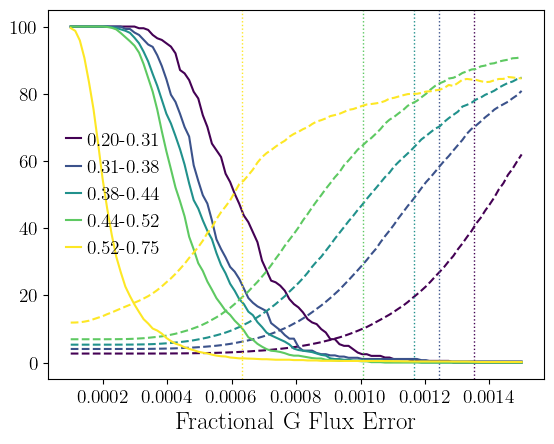

In [264]:
masspercs = [np.percentile(masses, percs[i]) for i in range(len(percs))]

cmap = plt.get_cmap("viridis")
colors = cmap(np.linspace(0,1,len(percs)-1))
for i in range(len(percs)-1):
    highr = np.zeros(len(dgs))
    vals = np.zeros(len(dgs))
    for dg in dgs:
        dg_mask = (delta_gs > dg)
        mask = (mdwarfs["phot_g_mean_flux"] > 0) & (masses > masspercs[i]) & (masses < masspercs[i+1])
        highr[np.argmin(np.abs(dgs - dg))] = np.sum(dg_mask & mask & (mdwarfs["ruwe"] > 1.4))/np.sum(mask & dg_mask)*100
        vals[np.argmin(np.abs(dgs - dg))] = np.sum(mask & dg_mask & (mdwarfs["solution_type"] > 5))/np.sum(mask & (mdwarfs["solution_type"] > 5))*100
    plt.plot(dgs, vals, color=colors[i], label=f"{masspercs[i]:.2f}-{masspercs[i+1]:.2f}")
    plt.plot(dgs, highr, color=colors[i], ls="--")
    plt.axvline(x=lims[i], color=colors[i], ls=":", lw=1)

plt.xlabel(r"Fractional G Flux Error");
plt.legend()
plt.show()

In [220]:
under_mask = np.zeros(len(mdwarfs), dtype=bool)

edges = np.percentile(masses, percs)
mass_arr = np.asarray(mdwarfs["mass"])
err = np.asarray(mdwarfs["phot_g_mean_flux_error"]) / np.asarray(mdwarfs["phot_g_mean_flux"])
bin_idx = np.searchsorted(edges, mass_arr, side="right") - 1
bin_idx = np.clip(bin_idx, 0, len(lims) - 1)
under_mask = err < lims[bin_idx]

/tmp/ipykernel_599754/2555291936.py:5: RuntimeWarning: invalid value encountered in divide
  err = np.asarray(mdwarfs["phot_g_mean_flux_error"]) / np.asarray(mdwarfs["phot_g_mean_flux"])


In [221]:
print_table(mdwarfs[~under_mask])

,All,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),100.00,41.84,57.85,0.13,0.10,0.07
Counts,15821,6620,9153,21,16,10


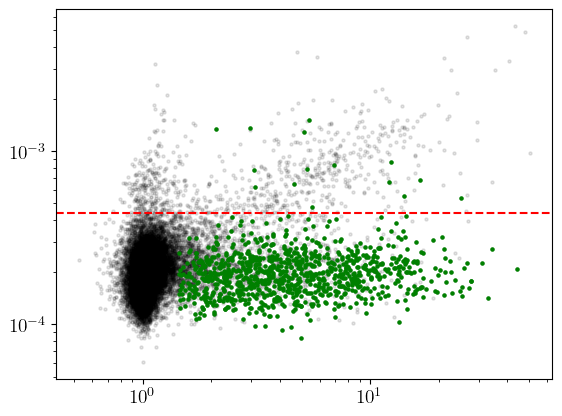

In [222]:
subset_mask = (mdwarfs["phot_g_mean_flux"] > 0) & (masses > np.percentile(masses, percs[-2])) & (masses < np.percentile(masses, percs[-1]))
high_soltype = mdwarfs["solution_type"] > 5
plt.scatter(mdwarfs[subset_mask]["ruwe"], mdwarfs[subset_mask]["phot_g_mean_flux_error"]/mdwarfs[subset_mask]["phot_g_mean_flux"], s=5, alpha=0.1)
plt.scatter(mdwarfs[subset_mask&high_soltype]["ruwe"], mdwarfs[subset_mask&high_soltype]["phot_g_mean_flux_error"]/mdwarfs[subset_mask&high_soltype]["phot_g_mean_flux"], s=5, color="g")
plt.axhline(y=lims[-1], c="r", ls="--")
plt.yscale("log")
plt.xscale("log")
plt.show()

/tmp/ipykernel_599754/4168178435.py:1: RuntimeWarning: invalid value encountered in divide
  plt.scatter(mdwarfs["mass_single"], mdwarfs["phot_g_mean_flux_error"]/mdwarfs["phot_g_mean_flux"], s=1, alpha=0.1)


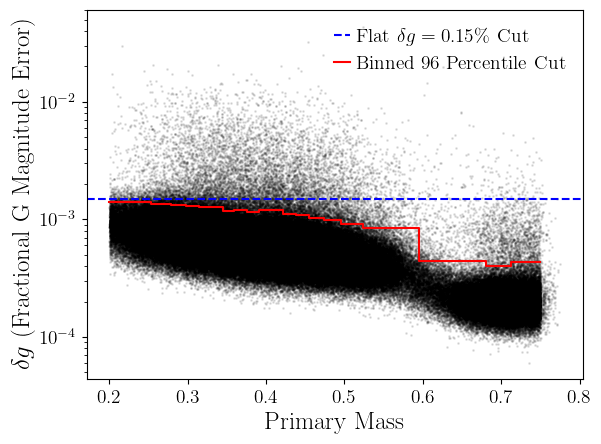

In [223]:
plt.scatter(mdwarfs["mass_single"], mdwarfs["phot_g_mean_flux_error"]/mdwarfs["phot_g_mean_flux"], s=1, alpha=0.1)
plt.axhline(y=0.0015, c="blue", ls="--", label=r"Flat $\delta g =0.15\%$ Cut")
#plt.scatter(mdwarfs[under_mask]["mass_single"], mdwarfs[under_mask]["phot_g_mean_flux_error"]/mdwarfs[under_mask]["phot_g_mean_flux"], s=1, alpha=0.1, color="r")
bounds = np.array([np.percentile(masses, p) for p in percs])
plt.plot(bounds.repeat(2)[1:-1], lims.repeat(2), c="r", label=r"Binned 96 Percentile Cut")
plt.yscale("log")
plt.legend()
plt.xlabel("Primary Mass");
plt.ylabel(r"$\delta g$ (Fractional G Magnitude Error)");
plt.show()

/tmp/ipykernel_1592976/2640841483.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout();


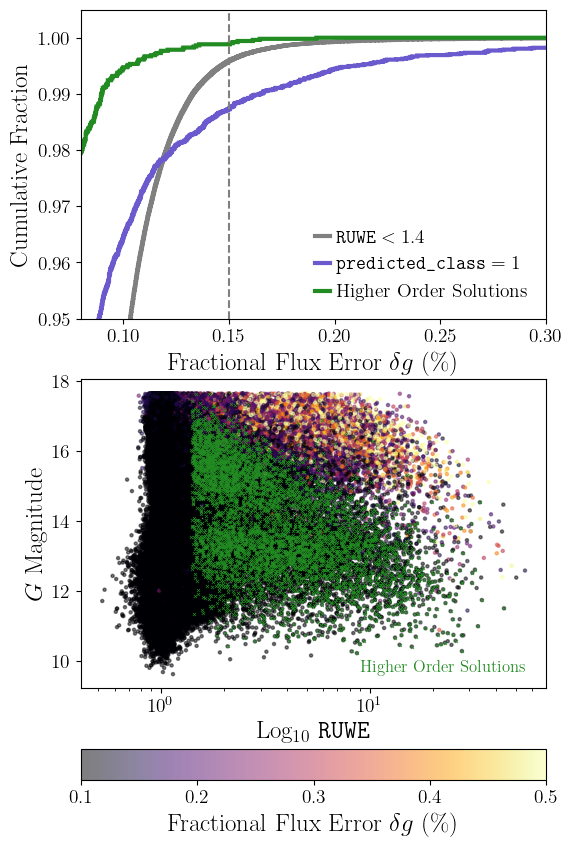

In [6]:
# Define samples
single = (
    100*mdwarfs[mdwarfs["solution_type"] == 0]["phot_g_mean_flux_error"]
    / mdwarfs[mdwarfs["solution_type"] == 0]["phot_g_mean_flux"]
)

predicted = (
    100*mdwarfs[mdwarfs["predicted_class"] == 1]["phot_g_mean_flux_error"]
    / mdwarfs[mdwarfs["predicted_class"] == 1]["phot_g_mean_flux"]
)

higher_order = (
    100*mdwarfs[mdwarfs["solution_type"] > 5]["phot_g_mean_flux_error"]
    / mdwarfs[mdwarfs["solution_type"] > 5]["phot_g_mean_flux"]
)

# EXACT same bins for all histograms
bins = np.linspace(
    min(single.min(), predicted.min(), higher_order.min()),
    max(single.max(), predicted.max(), higher_order.max()),
    10001,
)

def cumulative_density(data, bins):
    counts, edges = np.histogram(data, bins=bins, density=True)

    # Convert PDF histogram to cumulative distribution
    dx = np.diff(edges)
    cdf = np.cumsum(counts * dx)

    return cdf, edges

cdf_single, edges = cumulative_density(single, bins)
cdf_pred, _ = cumulative_density(predicted, bins)
cdf_high, _ = cumulative_density(higher_order, bins)

fig = plt.figure(figsize=(6, 10))
gs = fig.add_gridspec(
    3, 1,
    height_ratios=[1, 1, 0.1],  # small row for colorbar
    hspace=0.28
)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[2])

ax = ax1
ax.stairs(cdf_single, edges, linewidth=3, color="grey", label=r"$\texttt{RUWE}<1.4$")
ax.stairs(cdf_pred, edges, linewidth=3, color="slateblue", label=r"$\texttt{predicted\_class}=1$")
ax.stairs(cdf_high, edges, linewidth=3, color="forestgreen", label="Higher Order Solutions")

# Find 99.5% threshold
single_fractional_error = edges[:-1][np.argmin(np.abs(cdf_single - 0.995))]

ax.axvline(0.15, color="grey", linestyle="--")
#ax.axvline(single_fractional_error, color="green", linestyle="--")
#ax.axhline(0.995, color="grey", linestyle="--", zorder=0)
ax.set_xlim(0.08, 0.3)
ax.set_ylim(0.95, 1.005)
ax.set_xlabel(r"Fractional Flux Error $\delta g$ (\%)")
ax.set_ylabel("Cumulative Fraction")

ax.legend()

ax = ax2
cols = np.clip(mdwarfs["phot_g_mean_flux_error"]/mdwarfs["phot_g_mean_flux"], 1e-3, 0.005)*100
sc = ax.scatter(mdwarfs["ruwe"], mdwarfs["phot_g_mean_mag"], s=5, alpha=0.5, c=cols, cmap="inferno");#, norm=matplotlib.colors.PowerNorm(0.3, vmin=cols.min(), vmax=cols.max()));
ax.scatter(mdwarfs[mdwarfs["solution_type"] > 5]["ruwe"], mdwarfs[mdwarfs["solution_type"] > 5]["phot_g_mean_mag"], lw=0.5, s=5, marker="x", color="forestgreen", label="Higher Order Solutions");
ax.set_xscale("log");
ax.set_xlabel(r"Log$_{10}$ $\texttt{RUWE}$");
ax.set_ylabel(r"$G$ Magnitude");
ax.text(transform=ax.transAxes, x=0.60, y=0.05, s="Higher Order Solutions", color="forestgreen", fontsize=12);

cb = fig.colorbar(
    sc,
    cax=cax,
    orientation="horizontal",
)

cb.set_label(r"Fractional Flux Error $\delta g$ (\%)")
plt.tight_layout();
plt.savefig("./plots/FluxError.png", dpi=800, transparent=True, bbox_inches='tight');